(sec:mm)=
# Molecular mechanics

In [1]:
import veloxchem as vlx

In [2]:
molecule = vlx.Molecule.read_xyz_file("../input_files/hs276_optim_b3lyp_dev2-svp.xyz")

Let us assume we have a molecule for which we wish to construct a molecular mechanics (MM) force field.

In [3]:
molecule.show(atom_indices=True, width=600, height=450)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

(sec:mm-ff-gen)=
## Force field generation

An initial force field is created based on calculated RESP charges and tabulated GAFF parameters.

In [ ]:
import veloxchem as vlx
ff_gen = vlx.MMForceFieldGenerator()
ff_gen.create_topology(molecule)

* Info * Using 6-31G* basis set for RESP charges...                                                                       
* Info * Sum of partial charges is not a whole number.                                                                    
* Info * Compensating by removing 1.000e-06 from the largest charge.                                                      
                                                                                                                          
* Info * Using GAFF (v2.11) parameters.                                                                                   
         Reference: J. Wang, R. M. Wolf, J. W. Caldwell, P. A. Kollman, D. A. Case, J. Comput. Chem. 2004,
         25, 1157-1174.
                                                                                                                          
* Info * Updated bond angle 1-9-10 (ca-ca-cc) to 107.067 deg                                                              
* Info *

(sec:mm-ff-reparam)=
## Force field reparameterization

Rotatable bonds have been identified and stored by the force field generator.

In [6]:
print(ff_gen.rotatable_bonds)

[[14, 15], [21, 22], [28, 29], [29, 31], [31, 32]]


We will focus on the reparameterization of the barrier around the rotatable bond [21, 22], and make use of QM relaxed-scan reference data from file `16-21-22-27.xyz`.

                                          VeloxChem Dihedral Reparameterization                                           
                                                                                                                          
* Info * Rotatable bond selected: 21-22                                                                                   
* Info * Dihedrals involved:[[16, 21, 22, 23], [16, 21, 22, 27], [19, 21, 22, 23], [19, 21, 22, 27]]                      
                                                                                                                          
* Info * Reading QM scan from file...                                                                                     
* Info *   ../input_files/16-21-22-27.xyz                                                                                 
                                                                                                                          
* Info * Perform

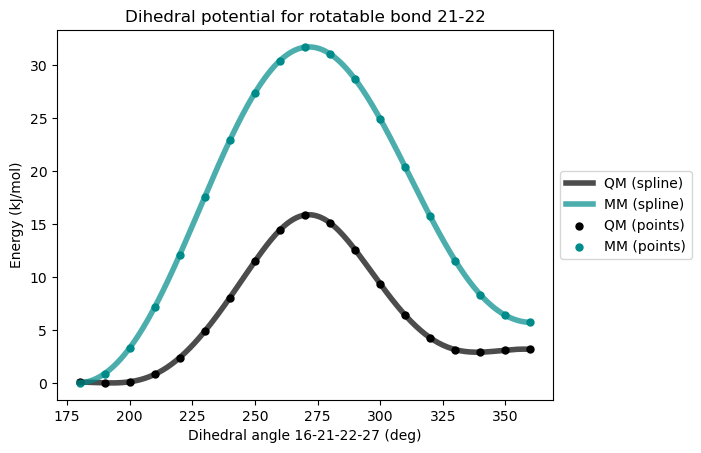

* Info * Fitting the dihedral parameters...                                                                               
* Info * Optimizing dihedral via least squares fitting...                                                                 
* Info * New fitted barriers: [2.22527117 2.22527117 2.22527117 2.22527117]                                               
                                                                                                                          
* Info * Validating the fitted force field...                                                                             
                                                                                                                          
* Info * Summary of validation                                                                                            
* Info * ---------------------                                                                                            
* Info * Maximum

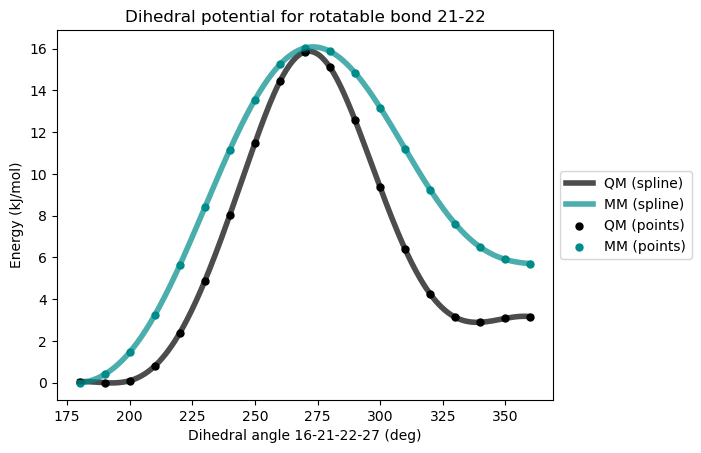

* Info * Dihedral MM parameters have been reparameterized and updated in the topology.                                    


In [7]:
reparam_results = ff_gen.reparameterize_dihedrals(
    rotatable_bond=(21, 22),
    scan_file="../input_files/16-21-22-27.xyz",
    visualize=True,
    verbose=False,
)

* Initial GAFF Force-field
:::{image} ../images/ff-reparam-1.png
:width: 400px
:align: center
:::

* After first reparametrization
:::{image} ../images/ff-reparam-2.png
:width: 400px
:align: center
:::

The rotational barrier is now much improved but the relative energies between the two conformer minima are still not well reproduced, leading to significant errors in the statistical dihedral distributions. As a remedy to this situation, an additional dihedral potential can be added.

In [8]:
ff_gen.add_dihedral((16, 21, 22, 27), barrier=0.0, phase=180.0, periodicity=1)

* Info * Added dihedral 16-21-22-27                                                                                       


We can now restart the reparametrization procedure with this added dihedral angle.

                                          VeloxChem Dihedral Reparameterization                                           
                                                                                                                          
* Info * Rotatable bond selected: 21-22                                                                                   
* Info * Dihedrals involved:[[16, 21, 22, 23], [16, 21, 22, 27], [19, 21, 22, 23], [19, 21, 22, 27]]                      
                                                                                                                          
* Info * Reading QM scan from file...                                                                                     
* Info *   ../input_files/16-21-22-27.xyz                                                                                 
                                                                                                                          
* Info * Perform

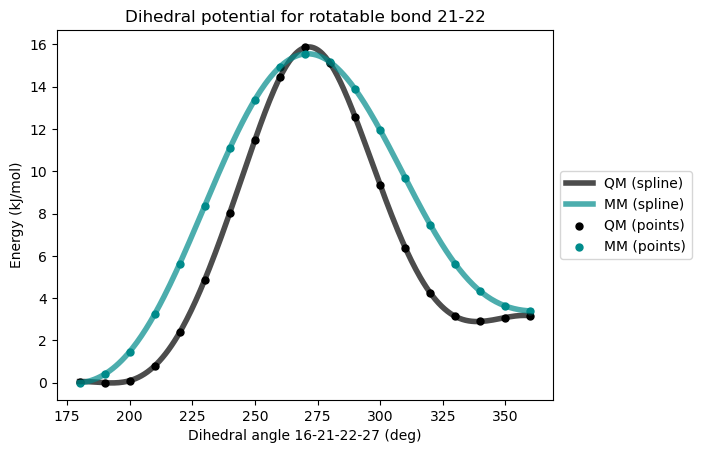

* Info * Dihedral MM parameters have been reparameterized and updated in the topology.                                    


In [9]:
reparam_results = ff_gen.reparameterize_dihedrals(
    rotatable_bond=(21, 22),
    scan_file="../input_files/16-21-22-27.xyz",
    visualize=True,
    verbose=False,
    initial_validation=False,
)

* After second reparametrization
:::{image} ../images/ff-reparam-3.png
:width: 400px
:align: center
:::

This time, both the barrier and the relative energy of the two minimun is well reproduced but the general shape of the potential energy surface can be improved to reach a better agreement with the QM potential. Another dihedral angle can be added for that purpose.

In [10]:
ff_gen.add_dihedral((16, 21, 22, 27), barrier=0.0, phase=0.0, periodicity=4)

* Info * Added dihedral 16-21-22-27                                                                                       


                                          VeloxChem Dihedral Reparameterization                                           
                                                                                                                          
* Info * Rotatable bond selected: 21-22                                                                                   
* Info * Dihedrals involved:[[16, 21, 22, 23], [16, 21, 22, 27], [19, 21, 22, 23], [19, 21, 22, 27]]                      
                                                                                                                          
* Info * Reading QM scan from file...                                                                                     
* Info *   ../input_files/16-21-22-27.xyz                                                                                 
                                                                                                                          
* Info * Perform

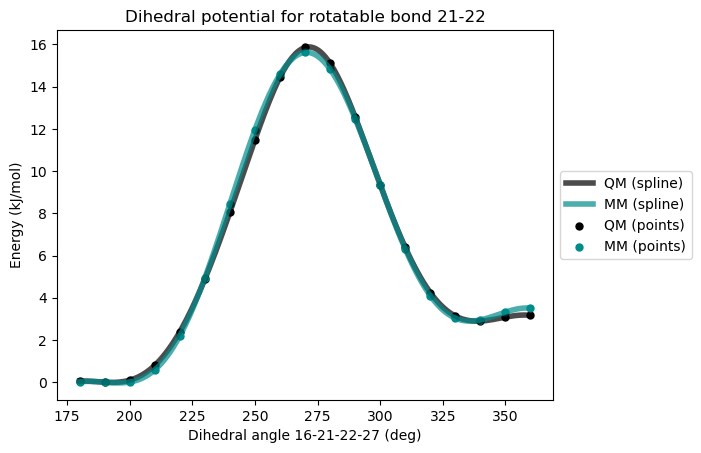

* Info * Dihedral MM parameters have been reparameterized and updated in the topology.                                    


In [11]:
reparam_results = ff_gen.reparameterize_dihedrals(
    rotatable_bond=(21, 22),
    scan_file="../input_files/16-21-22-27.xyz",
    visualize=True,
    verbose=False,
    initial_validation=False,
)

* After third reparametrization

:::{image} ../images/ff-reparam-4.png
:width: 400px
:align: center
:::

This time, the agreement betwwn the QM and MM potential is excellent. When a satisfactory quality has been reached in the force field, the files required to run GROMACS or OpenMM molecular dynamics simulations can be generated.

In [12]:
ff_gen.write_gromacs_files("HS-276_final", "MOL")
ff_gen.write_openmm_files("HS-276_final", "MOL")
